# Limpeza de dados

Mastercard Challenge 2026 — Inteli

O notebook 1 encontrou vários problemas nas bases. Aqui eu arrumo o que dá para arrumar e marco o que
não dá.

Regra que segui em tudo: **nenhuma linha é excluída**. Quando não tem conserto, crio uma coluna
`flag_alguma_coisa` com Sim/Não e deixo a linha lá. Quem for analisar decide se filtra.

O motivo é prático. Se eu apago 69 mil linhas de PIX porque acho que estão erradas e depois descubro
que o errado era o meu palpite, não tem como voltar, e ninguém revisando percebe que sumiram. Marcar
é reversível, apagar não é.

```python
df = df[df.valor > 0]                        # 917 linhas somem e ninguém sabe
df['flag_valor_impossivel'] = df.valor < 0   # 917 linhas marcadas
```

No final o notebook confere se alguma base perdeu linha e para com erro se tiver perdido.

Ordem: tipos e datas, vazios que significam algo, dados corrompidos, colunas que faltam, checagens de
consistência, escala do PIX, e salvar.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

PASTA = Path('.')
SAIDA = PASTA / 'bases_tratadas'
SAIDA.mkdir(exist_ok=True)

AZUL, LARANJA, VERDE, ROSA = '#2a78d6', '#eb6834', '#1baf7a', '#e87ba4'
TINTA, TINTA2, CINZA, GRADE, FUNDO = '#0b0b0b', '#52514e', '#8a8880', '#e6e5e1', '#fcfcfb'
mpl.rcParams.update({
    'figure.facecolor': FUNDO, 'axes.facecolor': FUNDO, 'savefig.facecolor': FUNDO,
    'axes.edgecolor': GRADE, 'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': GRADE, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': TINTA,
    'axes.titlelocation': 'left', 'axes.titlepad': 12, 'axes.labelcolor': TINTA2,
    'xtick.color': TINTA2, 'ytick.color': TINTA2, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.major.size': 0, 'ytick.major.size': 0, 'legend.frameon': False,
    'lines.linewidth': 2.0, 'font.size': 10, 'figure.dpi': 110,
})
mil = FuncFormatter(lambda v, p: f'{v:,.0f}'.replace(',', '.'))
pc  = FuncFormatter(lambda v, p: f'{v:.0f}%')

def n(x):   return f'{x:,.0f}'.replace(',', '.')
def brl(x): return ('R$ %s' % f'{x:,.2f}').replace(',', '@').replace('.', ',').replace('@', '.')

In [2]:
# Todo tratamento é registrado aqui. No final vira o relatório de qualidade.
DECISOES = []

def decisao(base, campo, problema, linhas, oquefiz, porque, descartei, tipo='tratamento'):
    DECISOES.append(dict(base=base, campo=campo, tipo=tipo, problema=problema,
                         linhas=linhas, decisao=oquefiz, por_que=porque, descartei=descartei))
    print(f'  [{tipo:<12}] {campo:<28} {n(linhas):>8} linhas   {oquefiz}')

def sim_nao(s):
    return s.astype(str).str.strip().str.lower().map({'sim': True, 'não': False, 'nao': False})

clientes = pd.read_csv(PASTA/'Base_clientes_v4.csv')
cartoes  = pd.read_csv(PASTA/'Base_cartoes_v4.csv')
transac  = pd.read_csv(PASTA/'Base_transacoes_v4.csv')
pix      = pd.read_csv(PASTA/'Base_pix_v4.csv')
invest   = pd.read_csv(PASTA/'Base_investimentos_v4.csv')

LINHAS_ANTES = {'clientes': len(clientes), 'cartoes': len(cartoes), 'transacoes': len(transac),
                'pix': len(pix), 'investimentos': len(invest)}
print(LINHAS_ANTES)

{'clientes': 1960, 'cartoes': 4006, 'transacoes': 156826, 'pix': 278940, 'investimentos': 21200}


## 1. Tipos e datas

Três formatos de data diferentes nas cinco bases: `04/04/1984`, `2023-01-01` e `202407` (que é um
número inteiro). Enquanto forem texto ou número, comparar datas não funciona — o Python compara
caractere por caractere.

Os Sim/Não também: em Python qualquer texto não vazio é verdadeiro, então `if cliente.Possui_Conta:`
dá True mesmo quando o valor é a string `"Não"`.

In [3]:
print('antes:', repr(clientes.Data_Nascimento.iloc[0]), '|', repr(invest.Data.iloc[0]))
print('comparando como texto: "04/04/1984" > "28/12/2006" ->', '04/04/1984' > '28/12/2006')
print('bool("Não") ->', bool('Não'))

clientes['Data_Nascimento']    = pd.to_datetime(clientes.Data_Nascimento, format='%d/%m/%Y', errors='coerce')
clientes['Data_Criacao_Conta'] = pd.to_datetime(clientes.Data_Criacao_Conta, errors='coerce')
cartoes['Data_Emissao']        = pd.to_datetime(cartoes.Data_Emissao, errors='coerce')
cartoes['Data_Ativacao']       = pd.to_datetime(cartoes.Data_Ativacao, errors='coerce')
cartoes['Data_Validade']       = pd.to_datetime(cartoes.Data_Validade, errors='coerce')
transac['Data']                = pd.to_datetime(transac.Data, errors='coerce')
pix['Data']                    = pd.to_datetime(pix.Data, errors='coerce')
invest['Data']                 = pd.to_datetime(invest.Data.astype(str), format='%Y%m', errors='coerce')
invest['Data_Abertura_Conta_Inv'] = pd.to_datetime(invest.Data_Abertura_Conta_Inv.astype(str),
                                                   format='%Y%m', errors='coerce')

clientes['Possui_Conta_Adicional'] = sim_nao(clientes.Possui_Conta_Adicional)
transac['Autorizado']              = sim_nao(transac.Autorizado)
pix['Agendado']                    = sim_nao(pix.Agendado)
pix['Aprovado']                    = pix.Aprovado.astype('boolean')
pix['Pix_para_si_mesmo']           = pix.Pix_para_si_mesmo.astype('boolean')

print('\ndepois:', clientes.Data_Nascimento.dtype, '|', invest.Data.dtype)
print(f'agora dá pra fazer conta direto: {clientes.Possui_Conta_Adicional.mean():.1%} têm conta adicional')

decisao('todas', 'datas', '3 formatos diferentes', 0, 'converter para datetime',
        'texto não se compara como data', 'comparar como texto, que quebra em silêncio')
decisao('todas', 'Sim/Não e 0/1', 'booleano guardado como texto e número', 0, 'converter para True/False',
        'a string "Não" é verdadeira em Python', 'comparar com == "Sim" em cada uso')

antes: '04/04/1984' | np.int64(202510)
comparando como texto: "04/04/1984" > "28/12/2006" -> False
bool("Não") -> True

depois: datetime64[us] | datetime64[us]
agora dá pra fazer conta direto: 21.2% têm conta adicional
  [tratamento  ] datas                               0 linhas   converter para datetime
  [tratamento  ] Sim/Não e 0/1                       0 linhas   converter para True/False


## 2. Vazio que significa alguma coisa

Nem toda célula vazia é dado perdido. Às vezes o vazio é a resposta — como o campo "nome do cônjuge"
em branco numa ficha, que não significa que a pessoa esqueceu, significa que ela é solteira.

Então antes de preencher qualquer coisa eu tento descobrir o que o vazio quer dizer.

### Qtd_Parcelas — 113 mil vazios

Minha primeira hipótese foi que vazio = compra à vista. Ela está errada, e o teste que derrubou foi
simples: se vazio fosse à vista, o número 1 não deveria existir na coluna. Ele existe 3.638 vezes.

In [4]:
print(transac.Qtd_Parcelas.value_counts().sort_index().to_string())

# então o que explica o vazio? cruzando com o canal da compra
cruz = pd.crosstab(transac.Tipo_Compra, transac.Qtd_Parcelas.isna(), normalize='index')
cruz.columns = ['preenchido', 'vazio']
print('\n', cruz.round(3).to_string(), sep='')
print(f'\ntransações CNP com o campo preenchido: '
      f'{transac.loc[transac.Tipo_Compra == "CNP", "Qtd_Parcelas"].notna().sum()}')

Qtd_Parcelas
1.0     3638
2.0     3508
3.0     3529
4.0     3662
5.0     3691
6.0     3620
7.0     3564
8.0     3706
9.0     3690
10.0    3669
11.0    3605
12.0    3692



             preenchido  vazio
Tipo_Compra                   
CNP               0.000  1.000
CP                0.397  0.603

transações CNP com o campo preenchido: 0


Nenhuma das 47 mil compras online tem o campo. Nenhuma. Isso não é comportamento de cliente, é falha
de captura no canal — e mesmo no presencial falta em 60% dos casos.

Então não dá para preencher. Deixo o vazio e crio `parcelado` com três estados: parcelado, à vista, ou
não sei. Se eu tivesse preenchido com 1, a taxa de parcelamento sairia 25,5% quando o que os dados
sustentam é 91,7% entre as compras em que o campo foi capturado.

In [5]:
transac['flag_parcelas_nao_informado'] = transac.Qtd_Parcelas.isna()
transac['parcelado'] = pd.Series(np.where(transac.Qtd_Parcelas.isna(), pd.NA, transac.Qtd_Parcelas > 1),
                                 index=transac.index, dtype='boolean')

print(transac.parcelado.value_counts(dropna=False).to_string())
print(f'\ntaxa de parcelamento entre os informados : {transac.parcelado.mean():.1%}')
print(f'taxa se eu tivesse preenchido com 1      : {(transac.Qtd_Parcelas.fillna(1) > 1).mean():.1%}')

decisao('transacoes', 'Qtd_Parcelas', 'vazio em 72% e em 100% das compras online', 113_252,
        'não preencher, criar flag e coluna de três estados',
        'o número 1 já existe na coluna e nenhuma compra CNP tem o campo, então é falha de captura',
        'preencher com 1, que derrubaria a taxa de parcelamento de 91,7% para 25,5%')

parcelado
<NA>     113252
True      39936
False      3638

taxa de parcelamento entre os informados : 91.7%
taxa se eu tivesse preenchido com 1      : 25.5%
  [tratamento  ] Qtd_Parcelas                  113.252 linhas   não preencher, criar flag e coluna de três estados


### Wallet, ativação em 1900 e vencimento em 2999

Três casos em que o vazio (ou o valor absurdo) tem significado claro:

- **Wallet** vazio em 86% das compras: quem paga com o cartão físico não usa Apple/Google/Samsung Pay.
  Vazio é "nenhuma", e isso é informação — só 14% das compras passam por carteira digital.
- **Data_Ativacao = 1900-01-01** em 450 cartões: é um valor sentinela, o jeito de sistemas antigos
  dizerem "não aconteceu". Se deixar, a média de dias até ativar fica negativa.
- **Data_de_vencimento = 299901** em 7.864 investimentos: mesma coisa, código para "não vence". Dá
  para confirmar: são 100% do produto Reservinha, que é o de liquidez diária.

In [6]:
# wallet
transac['usou_wallet'] = transac.Wallet.notna()
transac['Wallet'] = transac.Wallet.fillna('Sem wallet')
print(f'usa carteira digital: {transac.usou_wallet.mean():.1%} das compras')

# ativação sentinela
sentinela = cartoes.Data_Ativacao.dt.year <= 1900
print(f'\ncartões com ativação em 1900: {sentinela.sum()}   sem data de validade: {cartoes.Data_Validade.isna().sum()}'
      f'   em comum: {(sentinela & cartoes.Data_Validade.isna()).sum()}')
print(f'média de dias até ativar, com o 1900: {(cartoes.Data_Ativacao - cartoes.Data_Emissao).dt.days.mean():.0f}')
cartoes['ativado'] = cartoes.Data_Ativacao.dt.year > 1900
cartoes['Data_Ativacao'] = cartoes.Data_Ativacao.where(cartoes.ativado)
d = (cartoes.Data_Ativacao - cartoes.Data_Emissao).dt.days
print(f'média sem o 1900: {d.mean():.0f} dias   mediana: {d.median():.0f}   p75: {d.quantile(.75):.0f}')

# vencimento sentinela
perp = invest.Data_de_vencimento == 299901
print('\nquem usa o código 299901:')
print(invest.assign(p=perp).groupby('Produto_Investimento').p.mean().round(3).to_string())
invest['produto_perpetuo'] = perp
invest['Data_de_vencimento'] = pd.to_datetime(invest.Data_de_vencimento.where(~perp).astype('Int64').astype(str),
                                              format='%Y%m', errors='coerce')

decisao('transacoes', 'Wallet', 'vazio em 86%', 134_716, 'preencher com "Sem wallet" e criar usou_wallet',
        'vazio quer dizer que não passou por carteira digital', 'descartar a coluna e perder a métrica de adoção digital')
decisao('cartoes', 'Data_Ativacao', 'sentinela 1900-01-01', 450, 'virar vazio e criar flag ativado',
        'é código para "nunca ativado" e coincide com os 450 sem validade',
        'excluir os cartões, que são 11% do portfólio que nunca gerou receita')
decisao('investimentos', 'Data_de_vencimento', 'sentinela 299901', 7_864, 'virar vazio e criar produto_perpetuo',
        'é código para "sem vencimento" e são 100% Reservinha', 'manter o ano 2999 e quebrar qualquer gráfico de prazo')

usa carteira digital: 14.1% das compras

cartões com ativação em 1900: 450   sem data de validade: 450   em comum: 450
média de dias até ativar, com o 1900: -4993
média sem o 1900: 131 dias   mediana: 34   p75: 209

quem usa o código 299901:
Produto_Investimento
Renda Fixa        0.0
Renda Variavel    0.0
Reservinha        1.0
Tesouro Direto    0.0
  [tratamento  ] Wallet                        134.716 linhas   preencher com "Sem wallet" e criar usou_wallet
  [tratamento  ] Data_Ativacao                     450 linhas   virar vazio e criar flag ativado
  [tratamento  ] Data_de_vencimento              7.864 linhas   virar vazio e criar produto_perpetuo


### As 14 linhas de investimento sem valor, e os 255 clientes sem renda

As 14 linhas sem `Valor_Aplicado` nem `Saldo_Atual` têm `Data` igual à `Data_de_vencimento`. São
marcações de vencimento, não operações com valor perdido.

Já os 255 clientes sem renda eu **não** preencho, e esse é o caso mais importante do notebook. Eles
usam cartão e PIX igual ao resto da base, mas quase não investem. Preencher com a média deixaria o
campo bonito e apagaria o achado.

In [7]:
vazias = invest.Valor_Aplicado.isna() & invest.Saldo_Atual.isna()
print(f'linhas sem valor e sem saldo: {vazias.sum()}')
print(f'dessas, com Data == Data_de_vencimento: {(invest.loc[vazias, "Data"] == invest.loc[vazias, "Data_de_vencimento"]).sum()}')

invest['tipo_evento'] = np.where(vazias, 'Vencimento',
                        np.where(invest.Valor_Aplicado.fillna(0) < 0, 'Resgate', 'Aporte'))
invest['Valor_Aplicado'] = invest.Valor_Aplicado.fillna(0)
invest['Saldo_Atual']    = invest.Saldo_Atual.fillna(0)
print(invest.tipo_evento.value_counts().to_string())

# renda
clientes['cadastro_incompleto'] = clientes.Renda_Anual.isna()
comp = (clientes.assign(cartao=clientes.Cliente_ID.isin(transac.Cliente_ID),
                        pix_=clientes.Cliente_ID.isin(pix.Cliente_ID),
                        inv_=clientes.Cliente_ID.isin(invest.Cliente_ID))
        .groupby('cadastro_incompleto')[['cartao','pix_','inv_']].mean())
comp.index = ['renda informada', 'renda ausente']
print('\n', (100*comp).round(1).to_string(), sep='')
print(f'\ndiferença na taxa de investimento: {comp.inv_.iloc[0]/comp.inv_.iloc[1]:.0f}x')

decisao('investimentos', 'Valor_Aplicado e Saldo_Atual', 'os dois vazios na mesma linha', int(vazias.sum()),
        'marcar tipo_evento = Vencimento e zerar', 'a data da operação é igual à do vencimento',
        'apagar as 14 linhas e perder o registro do vencimento')
decisao('clientes', 'Renda_Anual', 'vazio em 13% dos clientes', 255,
        'não preencher, criar flag cadastro_incompleto',
        'esses clientes transacionam normal mas quase não investem, o vazio é o achado',
        'imputar pela mediana e apagar o insight')

linhas sem valor e sem saldo: 14
dessas, com Data == Data_de_vencimento: 14
tipo_evento
Aporte        19620
Resgate        1566
Vencimento       14

                 cartao  pix_  inv_
renda informada    73.0  72.8  58.0
renda ausente      73.3  74.1   5.5

diferença na taxa de investimento: 11x
  [tratamento  ] Valor_Aplicado e Saldo_Atual       14 linhas   marcar tipo_evento = Vencimento e zerar
  [tratamento  ] Renda_Anual                       255 linhas   não preencher, criar flag cadastro_incompleto


## 3. O que não tem conserto

### Crossborder e Contactless

Vazias em 95,6% e 82,5%. O problema não é só o volume: nos poucos preenchidos a divisão é 50/50, ou
seja, jogar uma moeda dá o mesmo resultado. Não uso nenhuma das duas. As colunas continuam no arquivo,
só ficam documentadas como inúteis.

### Os 917 PIX com valor negativo

Poderiam ser estornos. Não são — o maior PIX positivo da base é R$ 6.780 e a mediana desses negativos
é R$ 19.773 em módulo. 695 dos 917 são maiores que qualquer valor legítimo. Somam R$ -41 milhões.

In [8]:
neg = pix[pix.Valor < 0]
pos = pix.loc[pix.Valor > 0, 'Valor']
print(f'negativos: {len(neg)}   soma: {brl(neg.Valor.sum())}')
print(f'maior PIX positivo da base : {brl(pos.max())}')
print(f'mediana dos negativos      : {brl(neg.Valor.abs().median())}')
print(f'quantos passam do maior positivo: {(neg.Valor.abs() > pos.max()).sum()} de {len(neg)}')

pix['flag_valor_impossivel'] = pix.Valor < 0

for col in ['Crossborder', 'Contactless']:
    decisao('transacoes', col, f'vazio em {100*transac[col].isna().mean():.1f}% e 50/50 no resto',
            int(transac[col].isna().sum()), 'declarar inutilizável',
            'metade e metade é resultado de moeda jogada', 'preencher com 0 e inventar uma taxa falsa',
            tipo='documentação')
decisao('pix', 'Valor', 'negativos de até R$ -585.848', int(pix.flag_valor_impossivel.sum()),
        'marcar com flag_valor_impossivel e manter a linha',
        'não são estornos, 695 passam do maior positivo da base',
        'usar o valor absoluto e inventar R$ 41 mi de movimentação')

negativos: 917   soma: R$ -41.327.059,66
maior PIX positivo da base : R$ 6.779,76
mediana dos negativos      : R$ 19.773,00
quantos passam do maior positivo: 695 de 917
  [documentação] Crossborder                   149.912 linhas   declarar inutilizável
  [documentação] Contactless                   129.332 linhas   declarar inutilizável
  [tratamento  ] Valor                             917 linhas   marcar com flag_valor_impossivel e manter a linha


### As linhas de PIX sem data e sem tipo

418 sem `Data` e 418 sem `Tipo_transacao`. Números iguais, e a tentação é achar que são as mesmas
linhas. Não são: a interseção é zero, então são 836 linhas diferentes.

Isso muda o tratamento. Uma linha sem data mas com tipo ainda serve para contar quantos envios o
cliente fez; uma sem tipo mas com data ainda conta no volume do mês. Duas flags separadas.

### As 165 transações negativas

Aqui o negativo é legítimo. São estornos, todos autorizados, e ficam dentro da faixa normal de valores
— diferente do PIX, onde os negativos eram 3x maiores que qualquer positivo. Mesmo sintoma,
diagnóstico oposto. Crio uma coluna `tipo_evento` e preservo o sinal.

In [9]:
sem_data, sem_tipo = pix.Data.isna(), pix.Tipo_transacao.isna()
print(f'sem data: {sem_data.sum()}   sem tipo: {sem_tipo.sum()}   sem os dois: {(sem_data & sem_tipo).sum()}'
      f'   total atingido: {(sem_data | sem_tipo).sum()}')
pix['flag_sem_data'] = sem_data
pix['flag_sem_tipo'] = sem_tipo

est = transac[transac.Valor_Compra < 0]
print(f'\ntransações negativas: {len(est)}   todas autorizadas: {est.Autorizado.all()}')
print(f'soma: {brl(est.Valor_Compra.sum())}   maior em módulo: {brl(est.Valor_Compra.abs().max())}')
print(f'maior compra positiva da base: {brl(transac.Valor_Compra.max())}')
transac['tipo_evento'] = np.where(transac.Valor_Compra < 0, 'Estorno', 'Compra')

decisao('pix', 'Data', 'linhas sem data', int(sem_data.sum()), 'marcar com flag_sem_data',
        'sem data não entra em análise temporal mas ainda conta no total do cliente',
        'juntar com as sem tipo numa flag só, sendo que a interseção é zero', tipo='flag')
decisao('pix', 'Tipo_transacao', 'linhas sem direção', int(sem_tipo.sum()), 'marcar com flag_sem_tipo',
        'sem direção não entra no cálculo de fluxo mas a data está lá',
        'assumir que são envios e inventar direção em 418 transações', tipo='flag')
decisao('transacoes', 'Valor_Compra', 'negativos misturados com as compras', 165,
        'criar tipo_evento e preservar o sinal',
        'são estornos legítimos, dentro da faixa normal de valores',
        'excluir e superestimar a receita em R$ 132 mil', tipo='coluna nova')

sem data: 418   sem tipo: 418   sem os dois: 0   total atingido: 836

transações negativas: 165   todas autorizadas: True
soma: R$ -132.124,22   maior em módulo: R$ 3.996,53
maior compra positiva da base: R$ 107.777,62
  [flag        ] Data                              418 linhas   marcar com flag_sem_data
  [flag        ] Tipo_transacao                    418 linhas   marcar com flag_sem_tipo
  [coluna nova ] Valor_Compra                      165 linhas   criar tipo_evento e preservar o sinal


## 4. Colunas que faltam

Nada aqui está errado nas bases originais, é o que elas não têm. Tudo é derivado do que já existe.

- A base de cartões **não tem `Cliente_ID`**. Reconstruo pela base de transações. Sobram 469 cartões
  órfãos, e não é coincidência: 450 deles são os nunca ativados. Cartão que nunca foi usado não deixa
  rastro.
- A base de PIX **não tem chave primária**. Crio um `id_pix` sequencial.
- `Saldo_Atual` não é o saldo depois da operação, é o de antes. Descobri investigando por que o valor
  aplicado às vezes é maior que o saldo.

In [10]:
# a ponte cartão -> cliente é confiável? nenhum cartão pode aparecer com dois donos
print('cartões com mais de um cliente nas transações:',
      int((transac.groupby('ID_Cartao').Cliente_ID.nunique() > 1).sum()))

dono = transac.groupby('ID_Cartao').Cliente_ID.first()
cartoes['Cliente_ID']    = cartoes.ID_Cartao.map(dono).astype('Int64')
cartoes['flag_sem_dono'] = cartoes.Cliente_ID.isna()
cartoes['usado']         = cartoes.ID_Cartao.isin(transac.ID_Cartao)
orfaos = cartoes[cartoes.flag_sem_dono]
print(f'órfãos: {len(orfaos)} ({cartoes.flag_sem_dono.mean():.1%}), dos quais nunca ativados: {(~orfaos.ativado).sum()}')

pix.insert(0, 'id_pix', np.arange(1, len(pix) + 1))
print(f'\nduplicatas em (cliente, valor, segundo): '
      f'{pix.dropna(subset=["Data"]).assign(s=lambda d: d.Data.dt.floor("s")).duplicated(["Cliente_ID","Valor","s"]).sum()}')

decisao('cartoes', 'Cliente_ID', 'a base não tem a coluna', int(cartoes.flag_sem_dono.sum()),
        'reconstruir pela base de transações e marcar os órfãos',
        'é a única ponte e é segura, nenhum cartão aparece com dois clientes',
        'deduzir por proximidade de datas, que é chute numa coluna de chave', tipo='coluna nova')
decisao('pix', 'chave primária', 'a base não tem identificador', len(pix), 'criar id_pix sequencial',
        'sem chave não dá pra auditar linha nem rastrear reclamação',
        'concatenar cliente+data+valor, que quebra no primeiro empate', tipo='coluna nova')

cartões com mais de um cliente nas transações: 0
órfãos: 469 (11.7%), dos quais nunca ativados: 450



duplicatas em (cliente, valor, segundo): 0
  [coluna nova ] Cliente_ID                        469 linhas   reconstruir pela base de transações e marcar os órfãos
  [coluna nova ] chave primária                278.940 linhas   criar id_pix sequencial


In [11]:
# Saldo_Atual é o saldo antes ou depois da operação?
ord_ = invest.sort_values(['Cliente_ID','Produto_Investimento','Data']).copy()
g = ord_.groupby(['Cliente_ID','Produto_Investimento'])
ord_['ordem']    = g.cumcount()
ord_['ant']      = g.Valor_Aplicado.cumsum() - ord_.Valor_Aplicado

primeiras = ord_[ord_.ordem == 0]
resg      = ord_[ord_.Valor_Aplicado < 0]
print(f'primeiras operações com saldo zero          : {(primeiras.Saldo_Atual == 0).mean():.1%}')
print(f'saldo >= soma dos aportes anteriores        : {(ord_.Saldo_Atual >= ord_.ant - .01).mean():.1%}')
print(f'resgates que sacam exatamente o saldo       : {int(np.isclose(-resg.Valor_Aplicado, resg.Saldo_Atual).sum())}')
print(f'resgates que sacam mais que o saldo         : {int((-resg.Valor_Aplicado > resg.Saldo_Atual + .01).sum())}')

invest['saldo_fechamento'] = invest.Saldo_Atual + invest.Valor_Aplicado
print('\nexemplo (cliente 1009, Reservinha):')
print(invest[(invest.Cliente_ID == 1009) & (invest.Produto_Investimento == 'Reservinha')]
      .sort_values('Data')[['Data','Valor_Aplicado','Saldo_Atual','saldo_fechamento']]
      .to_string(index=False))

REF = pd.Timestamp('2025-12-31')   # data fixa, pra rodar amanhã dar o mesmo resultado
clientes['idade']         = ((REF - clientes.Data_Nascimento).dt.days / 365.25).round(0)
clientes['meses_de_casa'] = ((REF - clientes.Data_Criacao_Conta).dt.days / 30.44).round(0)

decisao('investimentos', 'Saldo_Atual', 'é o saldo antes da operação, o dicionário não diz isso', len(invest),
        'criar saldo_fechamento = Saldo_Atual + Valor_Aplicado',
        '74% das primeiras operações têm saldo zero e 432 resgates sacam exatamente o saldo',
        'confiar no dicionário, que é ambíguo e os dados contradizem', tipo='coluna nova')
decisao('clientes', 'idade e meses_de_casa', 'a base traz as datas mas não os derivados', len(clientes),
        'calcular com data de corte fixa em 31/12/2025',
        'data fixa garante que rodar amanhã dá o mesmo número',
        'usar a data de hoje e ter resultado que muda sozinho', tipo='coluna nova')

primeiras operações com saldo zero          : 73.7%
saldo >= soma dos aportes anteriores        : 100.0%
resgates que sacam exatamente o saldo       : 432
resgates que sacam mais que o saldo         : 0

exemplo (cliente 1009, Reservinha):
      Data  Valor_Aplicado  Saldo_Atual  saldo_fechamento
2024-04-01         1540.65         0.00           1540.65
2024-10-01         1512.04      1606.50           3118.54
2024-12-01         1808.56      3162.35           4970.91
2025-05-01         1980.87      5147.35           7128.22
2025-06-01         1566.80      7178.11           8744.91


  [coluna nova ] Saldo_Atual                    21.200 linhas   criar saldo_fechamento = Saldo_Atual + Valor_Aplicado
  [coluna nova ] idade e meses_de_casa           1.960 linhas   calcular com data de corte fixa em 31/12/2025


## 5. Checagens de consistência

Coisas que logicamente não podem acontecer. Cartão não é usado antes de ser ativado, cliente não faz
PIX antes de ter conta. Cada checagem é uma pergunta com resposta óbvia — e quando a base responde
"aconteceu 69 mil vezes", isso é o achado, não sujeira para varrer.

Não corrijo nada aqui, só marco. Corrigir exigiria saber qual dos dois campos está errado, e eu não
sei.

In [12]:
conta    = clientes.set_index('Cliente_ID').Data_Criacao_Conta
validade = cartoes.set_index('ID_Cartao').Data_Validade
ativacao = cartoes.set_index('ID_Cartao').Data_Ativacao
emissao  = cartoes.set_index('ID_Cartao').Data_Emissao
tipo_c   = cartoes.set_index('ID_Cartao').Tipo_Cartao
limite   = cartoes.set_index('ID_Cartao').Limite_Cartao

pix['flag_antes_da_conta']     = pix.Data < pix.Cliente_ID.map(conta)
transac['flag_cartao_vencido'] = transac.Data > transac.ID_Cartao.map(validade)
transac['flag_antes_ativacao'] = transac.Data < transac.ID_Cartao.map(ativacao)

eh_debito = transac.ID_Cartao.map(tipo_c) == 'Débito'
transac['flag_debito_parcelado'] = eh_debito & transac.parcelado.fillna(False)

clientes['flag_sem_atividade'] = ~(clientes.Cliente_ID.isin(transac.Cliente_ID)
                                   | clientes.Cliente_ID.isin(pix.Cliente_ID)
                                   | clientes.Cliente_ID.isin(invest.Cliente_ID))
invest['flag_vencimento_passado'] = (invest.Data_de_vencimento < invest.Data) & ~invest.produto_perpetuo

print(f'PIX antes da abertura da conta   : {n(pix.flag_antes_da_conta.sum())} ({pix.flag_antes_da_conta.mean():.1%})')
print(f'compra com cartão vencido        : {n(transac.flag_cartao_vencido.sum())} ({transac.flag_cartao_vencido.mean():.2%})')
print(f'compra antes da ativação         : {n(transac.flag_antes_ativacao.sum())} ({transac.flag_antes_ativacao.mean():.2%})')
print(f'compra antes da EMISSÃO          : {int((transac.Data < transac.ID_Cartao.map(emissao)).sum())}')
print(f'parcelamento em cartão de débito : {n(transac.flag_debito_parcelado.sum())}')
print(f'vencimento anterior à operação   : {int(invest.flag_vencimento_passado.sum())}')
print(f'cliente sem nenhuma movimentação : {int(clientes.flag_sem_atividade.sum())}')

PIX antes da abertura da conta   : 69.427 (24.9%)
compra com cartão vencido        : 2.700 (1.72%)
compra antes da ativação         : 2.131 (1.36%)


compra antes da EMISSÃO          : 0
parcelamento em cartão de débito : 6.852
vencimento anterior à operação   : 188
cliente sem nenhuma movimentação : 85


Alguns comentários sobre esses números:

**PIX antes da conta é o mais grave.** 69 mil linhas, um quarto da base, atingindo 1.121 dos 1.430
clientes com 292 dias de antecedência mediana. Ou o banco tem um problema de integridade entre
sistemas, ou as datas foram geradas de forma independente na montagem da base. Não dá pra afirmar qual
com os dados que temos.

**Compra antes da ativação dá zero para a emissão.** Nenhuma transação acontece antes do cartão ser
emitido, só entre emissão e ativação. Isso isola a `Data_Ativacao` como o campo suspeito — que é a
mesma coluna que usava 1900 como sentinela.

**Débito parcelado** são 92% das compras em débito que têm o campo preenchido. Débito debita na hora,
parcelamento não existe nesse produto.

In [13]:
# a checagem de limite quase virou um número falso
ingenuo = transac.Valor_Compra > transac.ID_Cartao.map(limite)
print(f'checagem ingênua (valor > limite): {n(ingenuo.sum())} ({ingenuo.mean():.1%})')
print(f'desses, em cartão de débito      : {n((ingenuo & eh_debito).sum())}')
print('\nlimite por tipo de cartão:')
print(cartoes.groupby('Tipo_Cartao').Limite_Cartao.median().to_string())

# débito tem limite zero, e isso está certo: débito usa saldo, não limite
transac['flag_acima_do_limite'] = (~eh_debito) & (transac.Valor_Compra > transac.ID_Cartao.map(limite))
print(f'\nchecagem correta, só crédito: {int(transac.flag_acima_do_limite.sum())} '
      f'({transac.flag_acima_do_limite.mean():.2%})')

checagem ingênua (valor > limite): 26.166 (16.7%)
desses, em cartão de débito      : 26.131

limite por tipo de cartão:
Tipo_Cartao
Crédito    19000.0
Débito         0.0

checagem correta, só crédito: 35 (0.02%)


Vale registrar esse último. A versão ingênua acusava 26 mil compras acima do limite, 17% da base — um
número escandaloso que teria virado slide. Quase todas eram cartão de débito, que tem limite zero
porque débito usa saldo em conta. Tirando o débito, sobram 35 casos, 0,03%. O problema praticamente
não existe.

In [14]:
for base, campo, prob, qtd, oq, pq, desc in [
    ('pix', 'Data vs abertura da conta', 'PIX antes do cliente existir', int(pix.flag_antes_da_conta.sum()),
     'marcar com flag_antes_da_conta', 'atinge 1.121 clientes com 292 dias de antecedência mediana',
     'corrigir a data no chute, sem saber qual sistema está errado'),
    ('transacoes', 'Data vs Data_Validade', 'compra com cartão vencido', int(transac.flag_cartao_vencido.sum()),
     'marcar com flag_cartao_vencido', 'foram aprovadas na mesma taxa das outras, então a validade não foi checada',
     'excluir 1,7% da base sem saber qual data é a culpada'),
    ('transacoes', 'Data vs Data_Ativacao', 'compra antes da ativação', int(transac.flag_antes_ativacao.sum()),
     'marcar com flag_antes_ativacao', 'a emissão nunca é violada, o que isola a Data_Ativacao',
     'ajustar a ativação para a primeira compra e apagar a evidência'),
    ('transacoes', 'parcelas vs tipo de cartão', 'parcelamento em débito', int(transac.flag_debito_parcelado.sum()),
     'marcar com flag_debito_parcelado', 'débito debita na hora, são 92% das compras de débito informadas',
     'zerar as parcelas e mascarar o problema'),
    ('transacoes', 'valor vs limite', 'compra acima do limite, só crédito', int(transac.flag_acima_do_limite.sum()),
     'marcar excluindo débito da checagem', 'a versão ingênua acusava 26 mil casos que eram débito com limite zero',
     'manter a checagem ingênua e reportar 17% falsos'),
    ('investimentos', 'vencimento vs data', 'vencimento anterior à operação', int(invest.flag_vencimento_passado.sum()),
     'marcar com flag_vencimento_passado', 'não dá pra aplicar em produto vencido, mas são 0,9%',
     'excluir, com impacto perto de zero'),
    ('clientes', 'atividade', 'cliente sem nenhuma movimentação', int(clientes.flag_sem_atividade.sum()),
     'marcar com flag_sem_atividade', 'não é erro, é segmento, e muda o denominador de qualquer média',
     'tratar como cadastro inválido e remover clientes reais'),
]:
    decisao(base, campo, prob, qtd, oq, pq, desc, tipo='flag')

  [flag        ] Data vs abertura da conta      69.427 linhas   marcar com flag_antes_da_conta
  [flag        ] Data vs Data_Validade           2.700 linhas   marcar com flag_cartao_vencido
  [flag        ] Data vs Data_Ativacao           2.131 linhas   marcar com flag_antes_ativacao
  [flag        ] parcelas vs tipo de cartão      6.852 linhas   marcar com flag_debito_parcelado
  [flag        ] valor vs limite                    35 linhas   marcar excluindo débito da checagem
  [flag        ] vencimento vs data                188 linhas   marcar com flag_vencimento_passado
  [flag        ] atividade                          85 linhas   marcar com flag_sem_atividade


## 6. A escala do PIX

Esse é o único tratamento que muda valores, então é o que precisa de mais justificativa.

De agosto de 2025 em diante o PIX típico salta de R$ 155 para R$ 640. O teste para saber se dá para
corrigir: se alguém multiplicou a coluna por um número, a razão entre os dois períodos tem que ser a
mesma em toda a distribuição.

                       pix 2025S2  transacoes 2024
razão no p5                 4.018            1.253
razão no p95                4.202            3.717
desvio das razões           0.046            0.697
coef. variação antes        1.108            0.835
coef. variação depois       1.107            1.068


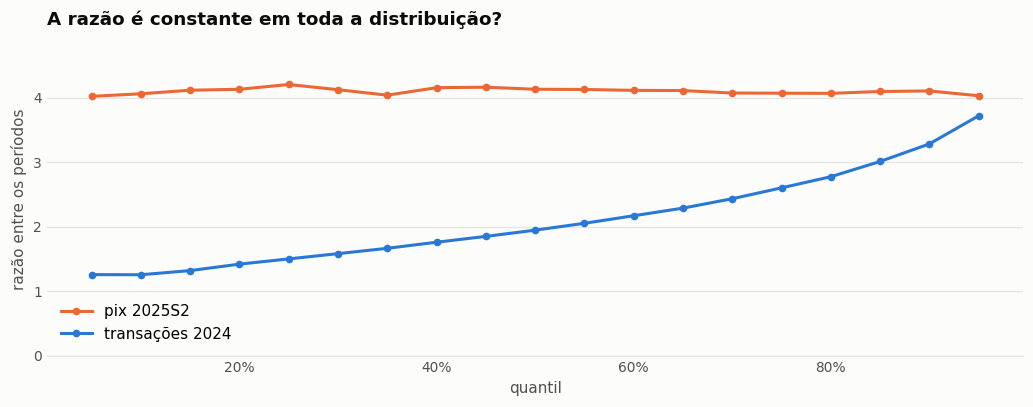

In [15]:
QS = np.arange(0.05, 1.00, 0.05)

ok_pix = pix[pix.Aprovado.fillna(False) & pix.Data.notna() & (pix.Valor > 0)]
ref_pix = ok_pix.loc[ok_pix.Data <  '2025-08-01', 'Valor']
alv_pix = ok_pix.loc[ok_pix.Data >= '2025-08-01', 'Valor']

ok_tx = transac[transac.Autorizado.fillna(False) & (transac.Valor_Compra > 0)]
ref_tx = ok_tx.loc[ok_tx.Data.dt.year != 2024, 'Valor_Compra']
alv_tx = ok_tx.loc[ok_tx.Data.dt.year == 2024, 'Valor_Compra']

razao_pix = alv_pix.quantile(QS).values / ref_pix.quantile(QS).values
razao_tx  = alv_tx.quantile(QS).values  / ref_tx.quantile(QS).values

comp = pd.DataFrame({
    'pix 2025S2':      [razao_pix.min(), razao_pix.max(), razao_pix.std(),
                        ref_pix.std()/ref_pix.mean(), alv_pix.std()/alv_pix.mean()],
    'transacoes 2024': [razao_tx.min(), razao_tx.max(), razao_tx.std(),
                        ref_tx.std()/ref_tx.mean(), alv_tx.std()/alv_tx.mean()]},
    index=['razão no p5', 'razão no p95', 'desvio das razões', 'coef. variação antes', 'coef. variação depois'])
print(comp.round(3).to_string())

fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.plot(QS*100, razao_pix, color=LARANJA, marker='o', markersize=4, label='pix 2025S2')
ax.plot(QS*100, razao_tx,  color=AZUL,    marker='o', markersize=4, label='transações 2024')
ax.set_ylim(0, max(razao_pix.max(), razao_tx.max())*1.15)
ax.xaxis.set_major_formatter(pc); ax.legend()
ax.set_xlabel('quantil'); ax.set_ylabel('razão entre os períodos')
ax.set_title('A razão é constante em toda a distribuição?')
plt.tight_layout(); plt.show()

No PIX a razão é uma reta em 4,13x do p5 ao p95, e o coeficiente de variação vai de 1,108 para 1,107 —
igual até a terceira casa. É reescala pura, dá para corrigir.

Nas transações a razão vai de 1,25 nas compras pequenas a 3,72 nas grandes. Não houve multiplicação,
mudou a distribuição inteira. Dividir por um número só não recupera nada.

Corrijo o PIX e mantenho a coluna `Valor` original ao lado, porque normalizar embute uma premissa: que
a escala mudou e o comportamento não. Estatisticamente isso é indistinguível de "todo mundo passou a
mandar PIX 4x maiores". O que decide a favor da primeira leitura é o contexto — a mudança é
instantânea e acontece no mês em que a base volta de sete meses de vazio. Quem discordar usa a coluna
original.

In [16]:
K = alv_pix.median() / ref_pix.median()
pix['Valor_norm'] = np.where(pix.Data >= '2025-08-01', pix.Valor / K, pix.Valor)
pix['flag_normalizado'] = pix.Data >= '2025-08-01'

print(f'fator: {K:.4f}   (mediana das razões p5..p95: {np.median(razao_pix):.4f})')
print(f'mediana antes da correção : {ref_pix.median():.2f} vs {alv_pix.median():.2f}')
print(f'mediana depois da correção: {ref_pix.median():.2f} vs {alv_pix.median()/K:.2f}')

# validação: o ticket do envio tem que ficar constante
env = pix[pix.Aprovado.fillna(False) & pix.Data.notna() & ~pix.flag_valor_impossivel
          & (pix.Tipo_transacao == 'Envio')].copy()
env['sem'] = env.Data.dt.year.astype(str) + 'S' + ((env.Data.dt.month > 6).astype(int) + 1).astype(str)
print('\nmediana do envio por semestre:')
print(env.groupby('sem')[['Valor','Valor_norm']].median().round(2).to_string())

decisao('pix', 'Valor', 'valores 4,13x maiores a partir de ago/2025', int(pix.flag_normalizado.sum()),
        f'criar Valor_norm dividindo por {K:.4f} e manter a original',
        'passou no teste de escala pura, razão constante e formato preservado',
        'substituir a coluna original e impedir a auditoria da premissa')
decisao('transacoes', 'Valor_Compra', 'em 2024 a distribuição é outra', 0,
        'não normalizar, valores de cartão seguem incomparáveis entre anos',
        'a razão vai de 1,25 a 3,72, não houve multiplicação',
        'dividir por um fator médio e errar nas duas pontas', tipo='documentação')

fator: 4.1286   (mediana das razões p5..p95: 4.1082)
mediana antes da correção : 154.96 vs 639.77
mediana depois da correção: 154.96 vs 154.96



mediana do envio por semestre:
         Valor  Valor_norm
sem                       
2023S1  153.59      153.59
2023S2  154.96      154.96
2024S1  152.88      152.88
2024S2  153.59      153.59
2025S2  636.08      154.07
  [tratamento  ] Valor                          63.707 linhas   criar Valor_norm dividindo por 4.1286 e manter a original
  [documentação] Valor_Compra                        0 linhas   não normalizar, valores de cartão seguem incomparáveis entre anos


Investigando por que as transações não normalizavam apareceu outra coisa, que muda como a base deve ser
usada: em 2023 e 2025 o `Valor_Compra` segue uma **distribuição uniforme entre R$ 0 e R$ 1.200**.

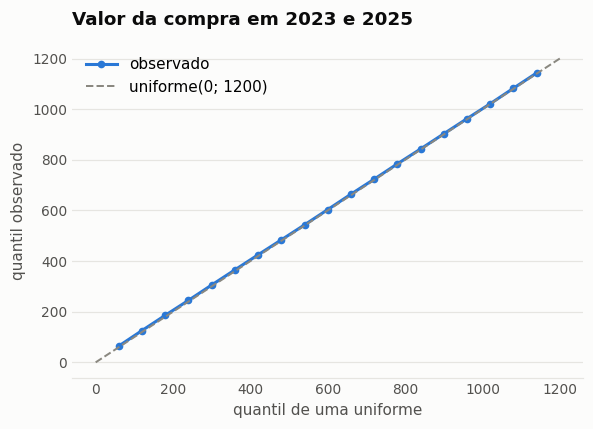

p25  observado R$     306    uniforme diria R$     300
p50  observado R$     603    uniforme diria R$     600
p75  observado R$     903    uniforme diria R$     900
p90  observado R$    1082    uniforme diria R$    1080

compras acima de R$ 1.200: 0.09%
  [documentação] Valor_Compra                        0 linhas   documentar que o valor não serve como variável analítica


In [17]:
teorico = 1200 * QS
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(teorico, ref_tx.quantile(QS).values, color=AZUL, marker='o', markersize=4, label='observado')
ax.plot([0, 1200], [0, 1200], color=CINZA, ls='--', lw=1.3, label='uniforme(0; 1200)')
ax.legend(); ax.set_xlabel('quantil de uma uniforme'); ax.set_ylabel('quantil observado')
ax.set_title('Valor da compra em 2023 e 2025')
plt.tight_layout(); plt.show()

for q in [.25, .5, .75, .9]:
    print(f'p{int(q*100):<3} observado R$ {ref_tx.quantile(q):>7.0f}    uniforme diria R$ {1200*q:>7.0f}')
print(f'\ncompras acima de R$ 1.200: {100*(ref_tx > 1200).mean():.2f}%')

decisao('transacoes', 'Valor_Compra', 'distribuição uniforme entre R$ 0 e R$ 1.200', 0,
        'documentar que o valor não serve como variável analítica',
        'os quantis caem na diagonal teórica e só 0,09% passa de R$ 1.200, o campo parece sorteado',
        'usar ticket médio e cliente de alto valor, que seriam métricas sobre número aleatório',
        tipo='documentação')

Consumo real não tem esse formato — gasto de cartão é assimétrico, muita compra pequena e pouca
grande. Uma reta perfeita indica que a coluna foi sorteada, não observada.

Na prática: ticket médio, "cliente de alto valor" e gasto por faixa de renda não são analisáveis nesta
base. É por isso que a correlação entre renda anual e gasto em 2025 é -0,05 — não tem nada para
correlacionar.

## 7. Conferir e salvar

A regra era não excluir nenhuma linha. Aqui eu confiro em vez de pedir que acreditem: se qualquer base
perdeu linha, o `assert` derruba o notebook e nada é salvo.

In [18]:
TRATADAS = {'clientes': clientes, 'cartoes': cartoes, 'transacoes': transac,
            'pix': pix, 'investimentos': invest}

falhou = False
for nome, df in TRATADAS.items():
    antes, depois = LINHAS_ANTES[nome], len(df)
    ok = antes == depois
    falhou |= not ok
    print(f'{"ok " if ok else "ERRO"}  {nome:<14} {n(antes):>9} -> {n(depois):>9}')
assert not falhou, 'alguma base perdeu linhas'

print('\nflags criadas:')
flags = []
for nome, df in TRATADAS.items():
    for f in [c for c in df.columns if c.startswith('flag_')]:
        q = int(df[f].fillna(False).sum())
        flags.append((nome, f, q, round(100*q/len(df), 2)))
        print(f'  {nome:<14} {f:<28} {n(q):>8}  ({100*q/len(df):>5.2f}%)')
flags = pd.DataFrame(flags, columns=['base','flag','linhas','pct'])

ok   clientes           1.960 ->     1.960
ok   cartoes            4.006 ->     4.006
ok   transacoes       156.826 ->   156.826
ok   pix              278.940 ->   278.940
ok   investimentos     21.200 ->    21.200

flags criadas:
  clientes       flag_sem_atividade                 85  ( 4.34%)
  cartoes        flag_sem_dono                     469  (11.71%)
  transacoes     flag_parcelas_nao_informado   113.252  (72.22%)
  transacoes     flag_cartao_vencido             2.700  ( 1.72%)
  transacoes     flag_antes_ativacao             2.131  ( 1.36%)
  transacoes     flag_debito_parcelado           6.852  ( 4.37%)
  transacoes     flag_acima_do_limite               35  ( 0.02%)
  pix            flag_valor_impossivel             917  ( 0.33%)
  pix            flag_sem_data                     418  ( 0.15%)
  pix            flag_sem_tipo                     418  ( 0.15%)
  pix            flag_antes_da_conta            69.427  (24.89%)
  pix            flag_normalizado               63.707

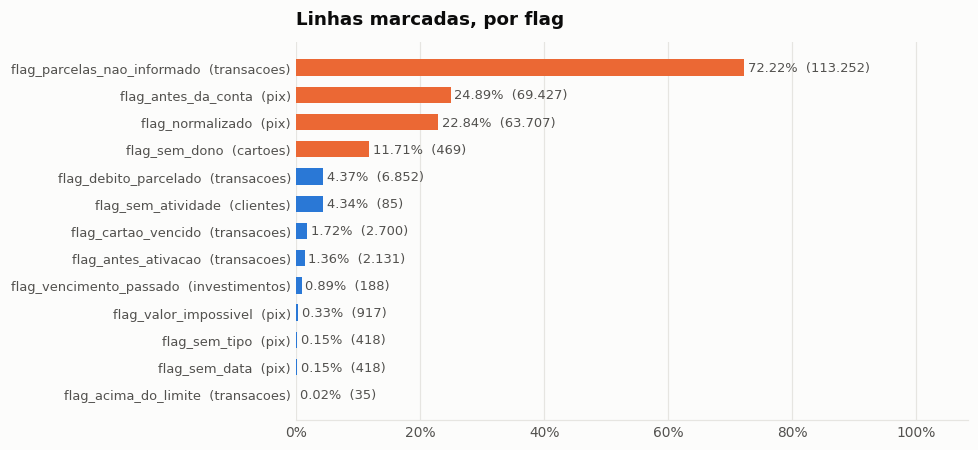

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.2))
f = flags.sort_values('pct')
y = range(len(f))
ax.barh(y, f.pct, height=0.6, color=[LARANJA if p > 10 else AZUL for p in f.pct])
ax.set_yticks(y, [f'{r.flag}  ({r.base})' for r in f.itertuples()], fontsize=8.5)
for yi, (p, q) in zip(y, zip(f.pct, f.linhas)):
    ax.text(p + 0.6, yi, f'{p:.2f}%  ({n(q)})', va='center', fontsize=8.5, color=TINTA2)
ax.grid(axis='x'); ax.grid(axis='y', visible=False); ax.set_xlim(0, f.pct.max()*1.5)
ax.xaxis.set_major_formatter(pc)
ax.set_title('Linhas marcadas, por flag')
plt.tight_layout(); plt.show()

In [20]:
for nome, df in TRATADAS.items():
    caminho = SAIDA / f'{nome}_tratado.csv'
    df.to_csv(caminho, index=False, encoding='utf-8-sig')
    print(f'{caminho.name:<28} {n(len(df)):>9} linhas  {df.shape[1]:>2} colunas  {caminho.stat().st_size/1e6:>5.1f} MB')

rel = pd.DataFrame(DECISOES)
rel.to_csv(PASTA/'relatorio_qualidade.csv', index=False, encoding='utf-8-sig')
flags.to_csv(PASTA/'relatorio_flags.csv', index=False, encoding='utf-8-sig')

print(f'\n{len(rel)} decisões registradas:')
print(rel.tipo.value_counts().to_string())
print('\nnenhuma linha excluída.')

clientes_tratado.csv             1.960 linhas  12 colunas    0.2 MB
cartoes_tratado.csv              4.006 linhas  11 colunas    0.4 MB


transacoes_tratado.csv         156.826 linhas  22 colunas   21.5 MB


pix_tratado.csv                278.940 linhas  15 colunas   31.6 MB
investimentos_tratado.csv       21.200 linhas  11 colunas    1.9 MB

28 decisões registradas:
tipo
tratamento      10
flag             9
coluna nova      5
documentação     4

nenhuma linha excluída.


Saíram cinco CSVs tratados em `bases_tratadas/` e dois relatórios. O notebook 3 usa esses arquivos.

Como usar:

```python
pix = pd.read_csv('bases_tratadas/pix_tratado.csv')

# somar valores: use a coluna normalizada e tire o que está corrompido
validos = pix[~pix.flag_valor_impossivel & ~pix.flag_sem_data]
total = validos.Valor_norm.sum()

# discorda da premissa da normalização? a coluna original está lá
total_sem_normalizar = validos.Valor.sum()
```

Uma última coisa: nenhuma decisão aqui é a única possível. Outro analista poderia, de boa fé, excluir
os 917 PIX corrompidos em vez de marcar, ou decidir não normalizar nada. O que não vale é tomar essas
decisões sem registrar — é por isso que cada uma tem também a alternativa que eu descartei, guardada no
`relatorio_qualidade.csv`.